# 🔬 SciPy — From Basic to Advanced

**SciPy** is an open-source Python library built on top of NumPy that provides a large collection of algorithms and mathematical tools for scientific and technical computing.

### Key Submodules
| Submodule | Purpose |
|---|---|
| `scipy.stats` | Statistical tests, distributions, descriptive statistics |
| `scipy.optimize` | Root finding, minimization, curve fitting |
| `scipy.linalg` | Linear algebra (extends numpy.linalg) |
| `scipy.integrate` | Numerical integration & ODE solvers |
| `scipy.interpolate` | 1D/ND interpolation |
| `scipy.signal` | Signal processing (filters, convolution, FFT) |
| `scipy.spatial` | Spatial data structures and algorithms |
| `scipy.sparse` | Sparse matrices & solvers |
| `scipy.ndimage` | N-dimensional image processing |
| `scipy.fft` | Fast Fourier Transforms |

In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

print(f'scipy  version: {scipy.__version__}')
print(f'numpy  version: {np.__version__}')

Matplotlib is building the font cache; this may take a moment.


scipy  version: 1.17.1
numpy  version: 2.4.6


---
## 📊 1. scipy.stats — Statistics

`scipy.stats` provides probability distributions, statistical tests, and descriptive statistics.
- **Distributions**: normal, t, chi2, binomial, poisson, uniform, etc.
- **Tests**: t-test, chi-square test, ANOVA, Kolmogorov-Smirnov, Mann-Whitney U, etc.
- Each distribution has methods: `pdf`, `cdf`, `ppf` (inverse CDF), `rvs` (random variates), `fit`.

### 1.1 Normal Distribution — PDF, CDF, PPF

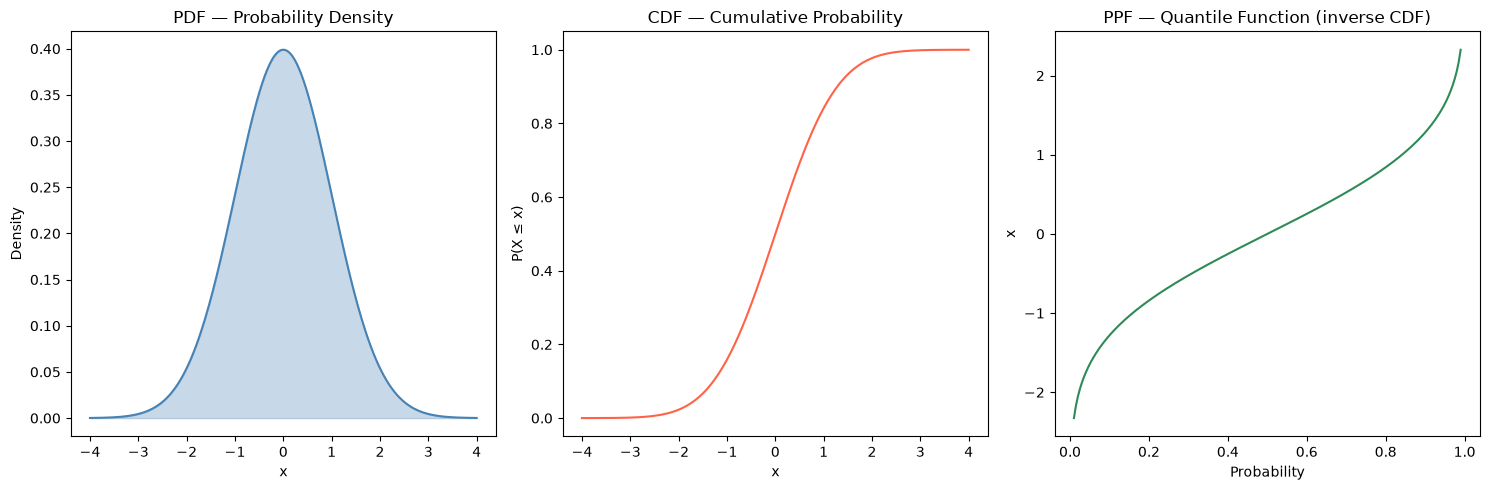

P(X < 1.96) = 0.9750
95th percentile = 1.6449


In [6]:
from scipy import stats

# Standard normal distribution (mean=0, std=1)
dist = stats.norm(loc=0, scale=1)

x = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(x, dist.pdf(x), color='steelblue')
axes[0].fill_between(x, dist.pdf(x), alpha=0.3, color='steelblue')
axes[0].set_title('PDF — Probability Density')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')

axes[1].plot(x, dist.cdf(x), color='tomato')
axes[1].set_title('CDF — Cumulative Probability')
axes[1].set_xlabel('x'); axes[1].set_ylabel('P(X ≤ x)')

p = np.linspace(0.01, 0.99, 200)
axes[2].plot(p, dist.ppf(p), color='seagreen')
axes[2].set_title('PPF — Quantile Function (inverse CDF)')
axes[2].set_xlabel('Probability'); axes[2].set_ylabel('x')

plt.tight_layout()
plt.show()

print(f'P(X < 1.96) = {dist.cdf(1.96):.4f}')   # ~0.975
print(f'95th percentile = {dist.ppf(0.95):.4f}')  # ~1.645

### 1.2 Descriptive Statistics

In [7]:
rng = np.random.default_rng(42)
data = rng.normal(loc=50, scale=10, size=200)

desc = stats.describe(data)
print('n         :', desc.nobs)
print('min/max   :', desc.minmax)
print('mean      :', round(desc.mean, 3))
print('variance  :', round(desc.variance, 3))
print('skewness  :', round(desc.skewness, 3))   # 0 → symmetric
print('kurtosis  :', round(desc.kurtosis, 3))   # 0 → normal (excess)

print('\nMode (approx):', round(stats.mode(data.round())[0], 2))
print('IQR           :', round(stats.iqr(data), 3))
print('Sem           :', round(stats.sem(data), 4))

n         : 200
min/max   : (np.float64(28.679537192686908), np.float64(79.1386246600733))
mean      : 49.695
variance  : 77.781
skewness  : 0.261
kurtosis  : -0.005

Mode (approx): 46.0
IQR           : 11.916
Sem           : 0.6236


### 1.3 Hypothesis Testing — One-sample & Two-sample t-tests

**t-test** checks if the mean of a sample differs significantly from a known value (one-sample) or from another group's mean (two-sample). The **p-value** < 0.05 typically means we reject the null hypothesis.

In [8]:
rng = np.random.default_rng(0)

# One-sample t-test: is mean == 50?
sample = rng.normal(loc=52, scale=5, size=30)
t_stat, p_val = stats.ttest_1samp(sample, popmean=50)
print('=== One-sample t-test (H0: mean=50) ===')
print(f't-statistic : {t_stat:.4f}')
print(f'p-value     : {p_val:.4f}')
print(f'Conclusion  : {"Reject H0" if p_val < 0.05 else "Fail to reject H0"}\n')

# Two-sample t-test: are group A and group B different?
group_a = rng.normal(loc=60, scale=8, size=40)
group_b = rng.normal(loc=65, scale=8, size=40)
t2, p2 = stats.ttest_ind(group_a, group_b)
print('=== Two-sample t-test (H0: means are equal) ===')
print(f't-statistic : {t2:.4f}')
print(f'p-value     : {p2:.4f}')
print(f'Conclusion  : {"Reject H0" if p2 < 0.05 else "Fail to reject H0"}')

=== One-sample t-test (H0: mean=50) ===
t-statistic : 1.8535
p-value     : 0.0740
Conclusion  : Fail to reject H0

=== Two-sample t-test (H0: means are equal) ===
t-statistic : -1.7456
p-value     : 0.0848
Conclusion  : Fail to reject H0


### 1.4 Chi-Square Test of Independence

Tests whether two categorical variables are independent. Given a contingency table, it compares observed vs expected frequencies.

In [9]:
# Contingency table: Gender vs Preference
# Rows: Male, Female  |  Cols: Product A, Product B, Product C
observed = np.array([
    [30, 20, 50],   # Male
    [40, 35, 25],   # Female
])

chi2, p, dof, expected = stats.chi2_contingency(observed)
print(f'Chi-square statistic : {chi2:.4f}')
print(f'p-value              : {p:.4f}')
print(f'Degrees of freedom   : {dof}')
print(f'Expected frequencies :\n{expected.round(2)}')
print(f'\nConclusion: {"Variables are NOT independent" if p < 0.05 else "Variables are independent"}')

Chi-square statistic : 13.8528
p-value              : 0.0010
Degrees of freedom   : 2
Expected frequencies :
[[35.  27.5 37.5]
 [35.  27.5 37.5]]

Conclusion: Variables are NOT independent


### 1.5 Pearson & Spearman Correlation

- **Pearson**: measures linear relationship (assumes normality).
- **Spearman**: measures monotonic relationship (rank-based, non-parametric).

Pearson  r=0.9709,  p=1.24e-62
Spearman r=0.9597, p=8.29e-56


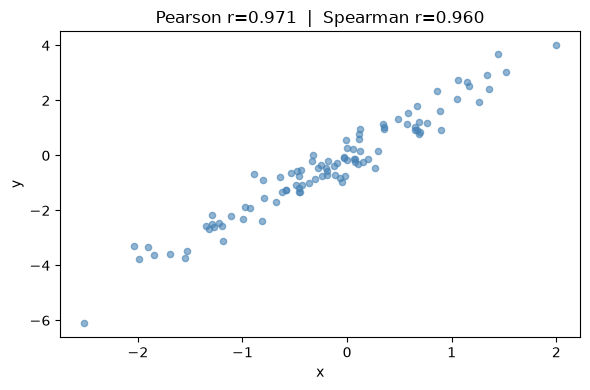

In [10]:
rng = np.random.default_rng(7)
x = rng.normal(size=100)
y = 2 * x + rng.normal(scale=0.5, size=100)  # strong positive correlation

pearson_r, pearson_p   = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

print(f'Pearson  r={pearson_r:.4f},  p={pearson_p:.2e}')
print(f'Spearman r={spearman_r:.4f}, p={spearman_p:.2e}')

plt.figure(figsize=(6, 4))
plt.scatter(x, y, alpha=0.6, color='steelblue', s=20)
plt.title(f'Pearson r={pearson_r:.3f}  |  Spearman r={spearman_r:.3f}')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

### 1.6 Kolmogorov-Smirnov Test — Normality Check

**KS test** checks whether a sample comes from a specified distribution. Useful for testing normality assumptions before applying parametric tests.

In [11]:
rng = np.random.default_rng(1)
normal_data  = rng.normal(size=100)
uniform_data = rng.uniform(size=100)

ks_n, p_n = stats.kstest(normal_data, 'norm')
ks_u, p_u = stats.kstest(uniform_data, 'norm')

print('Normal data  → KS={:.4f}, p={:.4f}  → {}'.format(ks_n, p_n, 'Normal ✓' if p_n > 0.05 else 'Not Normal ✗'))
print('Uniform data → KS={:.4f}, p={:.4f}  → {}'.format(ks_u, p_u, 'Normal ✓' if p_u > 0.05 else 'Not Normal ✗'))

Normal data  → KS=0.1202, p=0.1021  → Normal ✓
Uniform data → KS=0.5067, p=0.0000  → Not Normal ✗


---
## ⚡ 2. scipy.optimize — Optimization

`scipy.optimize` solves:
- **Root finding**: find x where f(x) = 0
- **Minimization**: find x that minimizes f(x)
- **Curve fitting**: fit a model function to data
- **Linear programming**: optimize a linear objective under constraints

### 2.1 Root Finding — brentq & fsolve

brentq root : 2.09455148
fsolve root : 2.09455148
f(root)     : -8.88e-16


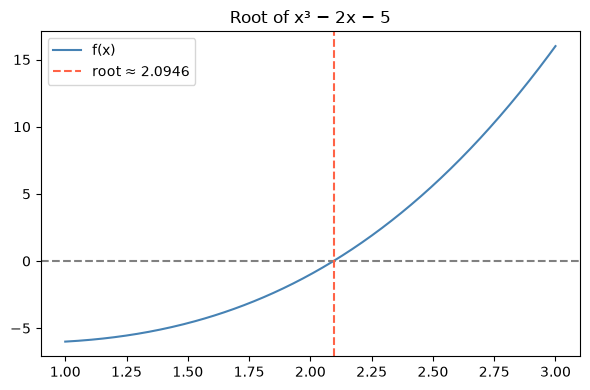

In [13]:
from scipy.optimize import brentq, fsolve

# Find root of f(x) = x^3 - 2x - 5
def f(x):
    return x**3 - 2*x - 5

root_brentq = brentq(f, 1, 3)  # bracket [1, 3]
root_fsolve = fsolve(f, x0=2)[0]  # initial guess

print(f'brentq root : {root_brentq:.8f}')
print(f'fsolve root : {root_fsolve:.8f}')
print(f'f(root)     : {f(root_brentq):.2e}')  # near zero

x = np.linspace(1, 3, 300)
plt.figure(figsize=(6, 4))
plt.plot(x, f(x), color='steelblue', label='f(x)')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(root_brentq, color='tomato', linestyle='--', label=f'root ≈ {root_brentq:.4f}')
plt.title('Root of x³ − 2x − 5')
plt.legend(); plt.tight_layout(); plt.show()

### 2.2 Minimization — minimize

`minimize` finds the minimum of a scalar function. Supports many methods: `Nelder-Mead`, `BFGS`, `L-BFGS-B`, `SLSQP`, etc.

In [ ]:
from scipy.optimize import minimize

# Rosenbrock function — classic optimization benchmark
def rosenbrock(xy):
    x, y = xy
    return (1 - x)**2 + 100 * (y - x**2)**2

result = minimize(rosenbrock, x0=[-1, 2], method='BFGS')
print('Minimization result:')
print(f'  Optimal x, y  : {result.x}')
print(f'  Min f(x,y)    : {result.fun:.6f}')
print(f'  Iterations    : {result.nit}')
print(f'  Success       : {result.success}')
print(f'  Message       : {result.message}')
# True minimum is at (1, 1) with f=0

### 2.3 Curve Fitting — curve_fit

`curve_fit` uses nonlinear least squares to fit a function to data. Returns optimal parameters and their covariance matrix.

In [ ]:
from scipy.optimize import curve_fit

# Model: exponential decay  f(x) = A * exp(-B * x) + C
def model(x, A, B, C):
    return A * np.exp(-B * x) + C

rng = np.random.default_rng(5)
x_data = np.linspace(0, 5, 80)
y_true = model(x_data, A=3.0, B=0.8, C=1.0)
y_noisy = y_true + rng.normal(scale=0.2, size=len(x_data))

popt, pcov = curve_fit(model, x_data, y_noisy, p0=[2, 1, 0.5])
A_fit, B_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))  # 1-sigma uncertainties

print(f'Fitted A = {A_fit:.4f} ± {perr[0]:.4f}  (true: 3.0)')
print(f'Fitted B = {B_fit:.4f} ± {perr[1]:.4f}  (true: 0.8)')
print(f'Fitted C = {C_fit:.4f} ± {perr[2]:.4f}  (true: 1.0)')

plt.figure(figsize=(7, 4))
plt.scatter(x_data, y_noisy, s=10, alpha=0.6, label='Noisy data')
plt.plot(x_data, model(x_data, *popt), color='tomato', lw=2, label='Fitted curve')
plt.plot(x_data, y_true, 'k--', lw=1, label='True curve')
plt.legend(); plt.title('Exponential Decay — Curve Fitting')
plt.tight_layout(); plt.show()

### 2.4 Linear Programming — linprog

**Linear programming** minimizes a linear objective subject to linear constraints.
Form: minimize **c·x** subject to **A_ub·x ≤ b_ub**, **A_eq·x = b_eq**, **lb ≤ x ≤ ub**.

In [ ]:
from scipy.optimize import linprog

# Maximize  5x1 + 4x2  →  minimize  -5x1 - 4x2
# Subject to:
#   6x1 + 4x2 <= 24
#   x1 + 2x2  <= 6
#   x1, x2 >= 0

c     = [-5, -4]           # negate for maximization
A_ub  = [[6, 4], [1, 2]]
b_ub  = [24, 6]
bounds = [(0, None), (0, None)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
print('Linear Programming Result')
print(f'  x1, x2         : {res.x}')
print(f'  Max objective  : {-res.fun:.4f}')  # negate back
print(f'  Status         : {res.message}')

---
## 🔢 3. scipy.linalg — Linear Algebra

`scipy.linalg` extends `numpy.linalg` with:
- **LU decomposition**: A = P·L·U
- **QR decomposition**: A = Q·R
- **Singular Value Decomposition (SVD)**: A = U·Σ·Vᵀ
- **Eigenvalue decomposition**, matrix functions, solving systems Ax=b efficiently.

### 3.1 Solving Linear Systems — Ax = b

In [ ]:
from scipy import linalg

# System:
#  2x + y - z = 8
# -3x - y + 2z = -11
# -2x + y + 2z = -3

A = np.array([
    [ 2,  1, -1],
    [-3, -1,  2],
    [-2,  1,  2]
], dtype=float)
b = np.array([8, -11, -3], dtype=float)

x = linalg.solve(A, b)
print(f'Solution x = {x}')  # Expected: [2, 3, -1]
print(f'Verification A @ x = {A @ x}')  # Should equal b
print(f'Residual norm ||Ax - b|| = {linalg.norm(A @ x - b):.2e}')

### 3.2 LU Decomposition

**LU decomposition** factors A into a lower triangular (L), upper triangular (U) and permutation (P) matrix. Used internally to solve linear systems efficiently.

In [ ]:
A = np.array([[2, 1, 1], [4, 3, 3], [8, 7, 9]], dtype=float)
P, L, U = linalg.lu(A)

print('P (permutation):\n', P)
print('L (lower triangular):\n', L.round(4))
print('U (upper triangular):\n', U.round(4))
print('P @ L @ U == A ?', np.allclose(P @ L @ U, A))

### 3.3 SVD — Singular Value Decomposition

**SVD** decomposes A = U·Σ·Vᵀ. Key applications:
- Dimensionality reduction (PCA)
- Low-rank matrix approximation
- Pseudo-inverse computation
- Noise removal

In [ ]:
rng = np.random.default_rng(10)
A = rng.normal(size=(4, 3))

U, s, Vt = linalg.svd(A)
print('A shape :', A.shape)
print('U shape :', U.shape)    # (4, 4)
print('s (singular values):', s.round(4))
print('Vt shape:', Vt.shape)   # (3, 3)

# Reconstruct A from SVD
Sigma = np.zeros_like(A)
Sigma[:3, :3] = np.diag(s)
A_reconstructed = U @ Sigma @ Vt
print('\nReconstruction error:', np.allclose(A, A_reconstructed))

# Low-rank approximation (keep top-2 singular values)
k = 2
A_lowrank = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
print(f'Low-rank (k={k}) approx error:', np.linalg.norm(A - A_lowrank).round(4))

### 3.4 Eigenvalues & Eigenvectors

In [ ]:
A = np.array([[4, -2], [1, 1]], dtype=float)
eigenvalues, eigenvectors = linalg.eig(A)

print('Eigenvalues :', eigenvalues)
print('Eigenvectors (columns):\n', eigenvectors)

# Verify: A @ v = λ * v
for i, lam in enumerate(eigenvalues):
    v = eigenvectors[:, i]
    Av = A @ v
    lv = lam * v
    print(f'\nλ={lam.real:.2f}: A@v={Av.real.round(4)}, λ*v={lv.real.round(4)}')

---
## ∫ 4. scipy.integrate — Numerical Integration

`scipy.integrate` computes integrals numerically when an analytic solution is hard or impossible:
- `quad`: single integration of a 1D function
- `dblquad`, `tplquad`: double/triple integrals
- `solve_ivp`: solve ordinary differential equations (ODE)

### 4.1 Definite Integration — quad

In [ ]:
from scipy.integrate import quad, dblquad

# Integrate f(x) = sin(x) from 0 to pi  →  should be 2
result, error = quad(np.sin, 0, np.pi)
print(f'∫sin(x)dx from 0 to π = {result:.10f}  (error ≈ {error:.2e})')

# Gaussian integral: ∫ exp(-x²) from -inf to inf  =  √π
def gaussian(x):
    return np.exp(-x**2)

result2, err2 = quad(gaussian, -np.inf, np.inf)
print(f'∫exp(-x²)dx from -∞ to ∞ = {result2:.10f}  (√π = {np.sqrt(np.pi):.10f})')

# Double integral: ∫∫ x*y dxdy over [0,1]×[0,1] = 0.25
result3, _ = dblquad(lambda y, x: x * y, 0, 1, 0, 1)
print(f'∫∫ x·y dxdy = {result3:.6f}  (expected: 0.25)')

### 4.2 Solving ODEs — solve_ivp

**ODE (Ordinary Differential Equation)** solver integrates systems of equations dy/dt = f(t, y). Example: simple harmonic oscillator.

In [ ]:
from scipy.integrate import solve_ivp

# Simple Harmonic Oscillator: d²x/dt² + ω²x = 0
# State: y = [x, dx/dt]  →  dy/dt = [dx/dt, -ω²x]
omega = 2.0  # angular frequency

def harmonic_oscillator(t, y):
    x, v = y
    return [v, -omega**2 * x]

y0 = [1.0, 0.0]   # initial: x=1, v=0
t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)

sol = solve_ivp(harmonic_oscillator, t_span, y0, t_eval=t_eval, method='RK45')

print(f'ODE solved successfully: {sol.success}')
print(f'Steps taken           : {len(sol.t)}')

# Analytical solution: x(t) = cos(ω*t)
x_analytical = np.cos(omega * t_eval)

plt.figure(figsize=(9, 4))
plt.plot(sol.t, sol.y[0], label='Position x(t) — numerical', color='steelblue')
plt.plot(t_eval, x_analytical, '--', label='cos(ωt) — analytical', color='tomato', alpha=0.8)
plt.plot(sol.t, sol.y[1], label='Velocity v(t)', color='seagreen', alpha=0.7)
plt.legend(); plt.xlabel('Time'); plt.title('Simple Harmonic Oscillator — solve_ivp')
plt.tight_layout(); plt.show()

---
## 📈 5. scipy.interpolate — Interpolation

**Interpolation** estimates values between known data points.
- `interp1d`: 1D interpolation (linear, quadratic, cubic, etc.)
- `CubicSpline`: piecewise cubic polynomial with smooth derivatives
- `RectBivariateSpline`, `griddata`: 2D/ND interpolation

### 5.1 1D Interpolation — interp1d & CubicSpline

In [ ]:
from scipy.interpolate import interp1d, CubicSpline

# Sparse data points
x_pts = np.array([0, 1, 2, 3, 4, 5])
y_pts = np.array([0, 0.8, 0.9, 0.1, -0.8, -1.0])

x_fine = np.linspace(0, 5, 300)

# Different interpolation kinds
f_linear  = interp1d(x_pts, y_pts, kind='linear')
f_cubic   = interp1d(x_pts, y_pts, kind='cubic')
cs        = CubicSpline(x_pts, y_pts)

plt.figure(figsize=(9, 4))
plt.scatter(x_pts, y_pts, color='black', zorder=5, label='Data points', s=60)
plt.plot(x_fine, f_linear(x_fine),  label='Linear',        linestyle='--')
plt.plot(x_fine, f_cubic(x_fine),   label='Cubic (interp1d)', lw=2)
plt.plot(x_fine, cs(x_fine),        label='CubicSpline',    lw=2, linestyle=':')
plt.legend(); plt.title('1D Interpolation Comparison')
plt.tight_layout(); plt.show()

### 5.2 2D Interpolation — griddata

In [ ]:
from scipy.interpolate import griddata

# Scattered 2D points
rng = np.random.default_rng(42)
n = 100
x_sc = rng.uniform(0, 4, n)
y_sc = rng.uniform(0, 4, n)
z_sc = np.sin(x_sc) * np.cos(y_sc)  # true surface

# Grid to interpolate onto
xi = np.linspace(0, 4, 100)
yi = np.linspace(0, 4, 100)
Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata((x_sc, y_sc), z_sc, (Xi, Yi), method='cubic')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x_sc, y_sc, c=z_sc, cmap='RdBu', s=20)
axes[0].set_title('Scattered Input Points')

im = axes[1].pcolormesh(Xi, Yi, Zi, cmap='RdBu', shading='auto')
plt.colorbar(im, ax=axes[1])
axes[1].set_title('2D Cubic Interpolation')

plt.tight_layout(); plt.show()

---
## 🔊 6. scipy.signal — Signal Processing

`scipy.signal` provides tools for:
- **Filtering**: low-pass, high-pass, band-pass filters (Butterworth, Chebyshev, etc.)
- **Convolution & correlation**: `convolve`, `correlate`
- **Peak detection**: `find_peaks`
- **Spectral analysis**: `periodogram`, `welch`
- **Resampling**: `resample`, `decimate`

### 6.1 Butterworth Low-Pass Filter

In [ ]:
from scipy.signal import butter, filtfilt, find_peaks

# Generate noisy signal
fs = 500       # sampling freq
t  = np.linspace(0, 1, fs, endpoint=False)
clean  = np.sin(2 * np.pi * 5 * t)            # 5 Hz signal
noise  = 0.5 * np.random.randn(len(t))        # noise
signal = clean + noise

# Butterworth low-pass filter (cutoff=20 Hz)
b, a = butter(N=4, Wn=20, btype='low', fs=fs)
filtered = filtfilt(b, a, signal)  # zero-phase filtering

plt.figure(figsize=(10, 4))
plt.plot(t, signal,   alpha=0.5, label='Noisy signal',  color='gray')
plt.plot(t, filtered, lw=2,      label='Filtered (LPF)', color='steelblue')
plt.plot(t, clean,   '--',       label='Clean signal',   color='tomato', alpha=0.8)
plt.legend(); plt.xlabel('Time (s)'); plt.title('Butterworth Low-Pass Filter')
plt.tight_layout(); plt.show()

### 6.2 Peak Detection — find_peaks

In [ ]:
from scipy.signal import find_peaks

# Multi-frequency signal
t = np.linspace(0, 2, 1000)
y = (np.sin(2 * np.pi * 3 * t) + 0.5 * np.sin(2 * np.pi * 7 * t)
     + 0.3 * np.random.randn(len(t)))

peaks, props = find_peaks(y, height=0.5, distance=30, prominence=0.4)

print(f'Found {len(peaks)} peaks')
print(f'Peak indices : {peaks[:5]}...')

plt.figure(figsize=(10, 4))
plt.plot(t, y, color='steelblue', alpha=0.8, label='Signal')
plt.scatter(t[peaks], y[peaks], color='tomato', zorder=5, s=50, label=f'{len(peaks)} peaks')
plt.legend(); plt.xlabel('Time'); plt.title('Peak Detection — find_peaks')
plt.tight_layout(); plt.show()

---
## 📐 7. scipy.spatial — Spatial Algorithms

`scipy.spatial` provides:
- **KD-Tree**: fast nearest-neighbor lookup in N dimensions
- **Convex Hull**: smallest convex polygon enclosing a point set
- **Voronoi Diagram**: partitions plane into regions by nearest point
- **Delaunay Triangulation**: mesh generation
- **Distance functions**: `cdist`, `pdist`

### 7.1 KD-Tree — Nearest Neighbor Search

In [ ]:
from scipy.spatial import KDTree

rng = np.random.default_rng(3)
points = rng.random((500, 2))  # 500 2D points
tree = KDTree(points)

# Query: 3 nearest neighbors to (0.5, 0.5)
query_pt = [0.5, 0.5]
distances, indices = tree.query(query_pt, k=5)

print('Query point:', query_pt)
print('5 Nearest neighbors (indices):', indices)
print('Distances                     :', distances.round(4))

# All points within radius 0.1
within = tree.query_ball_point(query_pt, r=0.1)
print(f'\nPoints within radius 0.1: {len(within)}')

plt.figure(figsize=(6, 5))
plt.scatter(points[:, 0], points[:, 1], s=5, alpha=0.4, color='steelblue')
plt.scatter(*query_pt, color='black', zorder=5, s=100, label='Query')
plt.scatter(points[indices, 0], points[indices, 1], color='tomato', s=60, label='k-NN')
plt.legend(); plt.title('KD-Tree — 5 Nearest Neighbors')
plt.tight_layout(); plt.show()

### 7.2 Convex Hull & Voronoi Diagram

In [ ]:
from scipy.spatial import ConvexHull, Voronoi, voronoi_plot_2d

rng = np.random.default_rng(8)
pts = rng.random((20, 2))

hull = ConvexHull(pts)
vor  = Voronoi(pts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Convex Hull
axes[0].scatter(pts[:, 0], pts[:, 1], color='steelblue', zorder=5)
for simplex in hull.simplices:
    axes[0].plot(pts[simplex, 0], pts[simplex, 1], 'tomato')
axes[0].set_title(f'Convex Hull  (area={hull.volume:.4f})')

# Voronoi
voronoi_plot_2d(vor, ax=axes[1], show_vertices=False, line_colors='tomato', line_alpha=0.6)
axes[1].scatter(pts[:, 0], pts[:, 1], color='steelblue', zorder=5)
axes[1].set_xlim(-0.1, 1.1); axes[1].set_ylim(-0.1, 1.1)
axes[1].set_title('Voronoi Diagram')

plt.tight_layout(); plt.show()
print(f'Convex hull vertices: {hull.vertices}')

### 7.3 Pairwise Distances — cdist & pdist

In [ ]:
from scipy.spatial.distance import cdist, pdist, squareform

A = np.array([[1, 2], [3, 4], [5, 6]])
B = np.array([[0, 0], [1, 1]])

# cdist: all pairwise distances between two sets
D = cdist(A, B, metric='euclidean')
print('cdist(A, B) — Euclidean:')
print(D.round(4))

# pdist: all pairwise distances within one set
dists = pdist(A, metric='euclidean')
print('\npdist(A) — upper triangle:', dists.round(4))
print('squareform:\n', squareform(dists).round(4))

# Other metrics
print('\nCosine distance cdist(A,B):')
print(cdist(A, B, metric='cosine').round(4))

---
## 🌀 8. scipy.fft — Fast Fourier Transform

**FFT** transforms a signal from the time domain to the frequency domain.
- Reveals dominant frequencies in a signal
- Core of audio processing, image compression (JPEG), spectral analysis
- `fft`: compute the FFT
- `fftfreq`: compute the corresponding frequency bins
- `rfft`/`irfft`: real-valued FFT (more efficient for real signals)

### 8.1 FFT — Frequency Analysis

In [ ]:
from scipy.fft import fft, fftfreq, rfft, rfftfreq

# Signal: 5 Hz + 15 Hz + 30 Hz components
fs = 1000    # sampling freq Hz
N  = 1000    # samples
t  = np.linspace(0, 1, N, endpoint=False)

signal = (1.0 * np.sin(2 * np.pi * 5  * t)
        + 0.5 * np.sin(2 * np.pi * 15 * t)
        + 0.3 * np.sin(2 * np.pi * 30 * t))

# Compute FFT
freqs  = rfftfreq(N, d=1/fs)   # positive frequencies only
mag    = np.abs(rfft(signal)) * 2 / N  # normalize

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(t[:200], signal[:200], color='steelblue')
axes[0].set_title('Time Domain Signal (first 200 samples)')
axes[0].set_xlabel('Time (s)')

axes[1].stem(freqs[:100], mag[:100], markerfmt='o', linefmt='steelblue', basefmt='gray')
axes[1].set_title('Frequency Domain (FFT Magnitude)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout(); plt.show()

# Identify top frequencies
top_idx = np.argsort(mag)[::-1][:5]
print('Top 5 frequencies (Hz):', freqs[top_idx].round(1))

---
## 🕸 9. scipy.sparse — Sparse Matrices

**Sparse matrices** store only non-zero elements, drastically saving memory for large, mostly-zero matrices (e.g., adjacency matrices, NLP term-document matrices).
- **CSR** (Compressed Sparse Row): fast row slicing & matrix-vector products
- **CSC** (Compressed Sparse Column): fast column operations
- **COO**: easy to construct
- `scipy.sparse.linalg`: sparse solvers (`spsolve`, `eigs`, `svds`)

### 9.1 Creating & Operating on Sparse Matrices

In [ ]:
import scipy.sparse as sp

# Build sparse matrix from dense
dense = np.array([
    [1, 0, 0, 2],
    [0, 0, 3, 0],
    [4, 0, 0, 0],
    [0, 5, 0, 6]
])

sparse_csr = sp.csr_matrix(dense)
print('Sparse CSR matrix:')
print(sparse_csr)

print(f'\nShape        : {sparse_csr.shape}')
print(f'Stored (nnz) : {sparse_csr.nnz}  non-zeros out of {dense.size}')
print(f'Sparsity     : {1 - sparse_csr.nnz/dense.size:.1%}')
print(f'\nDense repr:\n{sparse_csr.toarray()}')

### 9.2 Sparse Matrix-Vector Multiply & Solver

In [ ]:
from scipy.sparse.linalg import spsolve

# Build a sparse diagonal system (like discretized 1D PDE)
n = 5
diagonals = [
    -1 * np.ones(n-1),  # sub-diagonal
     2 * np.ones(n),    # main diagonal
    -1 * np.ones(n-1),  # super-diagonal
]
A_sparse = sp.diags(diagonals, offsets=[-1, 0, 1], format='csr')
b_vec = np.array([1, 0, 0, 0, 1], dtype=float)

print('A (sparse tridiagonal):\n', A_sparse.toarray())
print('b:', b_vec)

x_sol = spsolve(A_sparse, b_vec)
print(f'\nSolution x : {x_sol.round(4)}')
print(f'Residual   : {np.linalg.norm(A_sparse @ x_sol - b_vec):.2e}')

---
## 🖼 10. scipy.ndimage — N-D Image Processing

`scipy.ndimage` performs N-dimensional image operations:
- **Filters**: Gaussian blur, median filter, Sobel edge detection
- **Morphology**: erosion, dilation, binary opening/closing
- **Measurements**: label connected components, find objects, center of mass
- Works on arbitrary N-dimensional arrays (images, volumes, etc.)

### 10.1 Gaussian Blur & Edge Detection

In [ ]:
from scipy.ndimage import gaussian_filter, sobel, median_filter

# Create a synthetic image
rng = np.random.default_rng(20)
img = np.zeros((100, 100))
img[25:75, 25:75] = 1.0   # white square
img += rng.normal(scale=0.2, size=img.shape)  # add noise

blurred  = gaussian_filter(img, sigma=3)
edge_x   = sobel(img, axis=1)
edge_y   = sobel(img, axis=0)
edges    = np.hypot(edge_x, edge_y)
denoised = median_filter(img, size=5)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
titles = ['Noisy Image', 'Gaussian Blur', 'Sobel Edges', 'Median Filter']
images = [img, blurred, edges, denoised]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray'); ax.set_title(title); ax.axis('off')

plt.tight_layout(); plt.show()

### 10.2 Connected Component Labeling

In [ ]:
from scipy.ndimage import label, find_objects

# Binary image with several blobs
binary = np.zeros((50, 50), dtype=int)
binary[5:15,  5:15]  = 1  # blob 1
binary[20:35, 20:35] = 1  # blob 2
binary[5:10,  35:45] = 1  # blob 3

labeled_arr, num_features = label(binary)
print(f'Number of connected components: {num_features}')

slices = find_objects(labeled_arr)
for i, sl in enumerate(slices):
    print(f'Component {i+1}: rows {sl[0]}, cols {sl[1]}')

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(binary, cmap='gray'); plt.title('Binary Image'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(labeled_arr, cmap='tab10'); plt.title('Labeled Components'); plt.axis('off')
plt.tight_layout(); plt.show()

---
## 🔁 Summary

| Topic | Key Functions Used |
|---|---|
| **Stats — Distributions** | `stats.norm`, `pdf`, `cdf`, `ppf`, `rvs` |
| **Stats — Descriptive** | `stats.describe`, `stats.iqr`, `stats.sem` |
| **Stats — Hypothesis Tests** | `ttest_1samp`, `ttest_ind`, `chi2_contingency`, `kstest` |
| **Stats — Correlation** | `stats.pearsonr`, `stats.spearmanr` |
| **Optimize — Root Finding** | `brentq`, `fsolve` |
| **Optimize — Minimization** | `minimize` (BFGS, Nelder-Mead) |
| **Optimize — Curve Fitting** | `curve_fit` |
| **Optimize — Linear Prog** | `linprog` |
| **Linear Algebra** | `linalg.solve`, `linalg.lu`, `linalg.svd`, `linalg.eig` |
| **Integration** | `quad`, `dblquad`, `solve_ivp` |
| **Interpolation** | `interp1d`, `CubicSpline`, `griddata` |
| **Signal Processing** | `butter`, `filtfilt`, `find_peaks` |
| **Spatial** | `KDTree`, `ConvexHull`, `Voronoi`, `cdist`, `pdist` |
| **FFT** | `fft`, `rfft`, `rfftfreq` |
| **Sparse Matrices** | `sp.csr_matrix`, `sp.diags`, `spsolve` |
| **Image Processing** | `gaussian_filter`, `sobel`, `median_filter`, `label` |